<a href="https://colab.research.google.com/github/KENE508/Customer-Churn-Analysis-and-Retention-Strategies/blob/main/Customer_Churn_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
cc_data = pd.read_csv('/content/drive/My Drive/csv_folders/Customer_Churn.csv')
cc_data.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)
cc_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
cc_data.rename(columns={'Exited': 'Churn'}, inplace=True)  # To show that the tenure column is made up of just months and we don't have up tp 12 months in the coiumn

In [ ]:
churn_rate = cc_data["Churn"].value_counts(normalize=True) # TO GET THE RATE AT WHICH CUSTOMERS CHURN
churn_rate

,proportion
Churn,
0,0.7963
1,0.2037


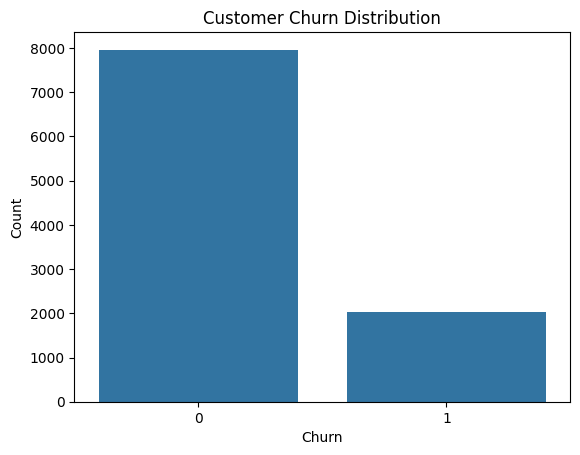

In [ ]:
sns.countplot(x='Churn', data=cc_data)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

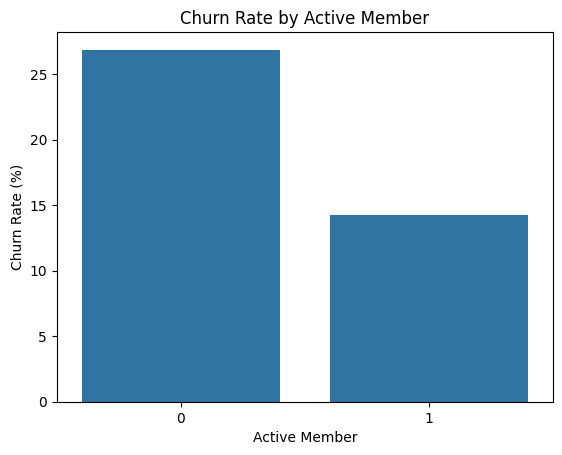

In [ ]:
act_churn = cc_data.groupby("IsActiveMember")["Churn"].mean()*100 # PERCENTAGE RATE AT WHICH ACTIVE AND NONE ACTIVE CUSTOMERS CHURN
sns.barplot(x=act_churn.index, y=act_churn)
plt.title("Churn Rate by Active Member")
plt.xlabel("Active Member")
plt.ylabel("Churn Rate (%)")
plt.show()

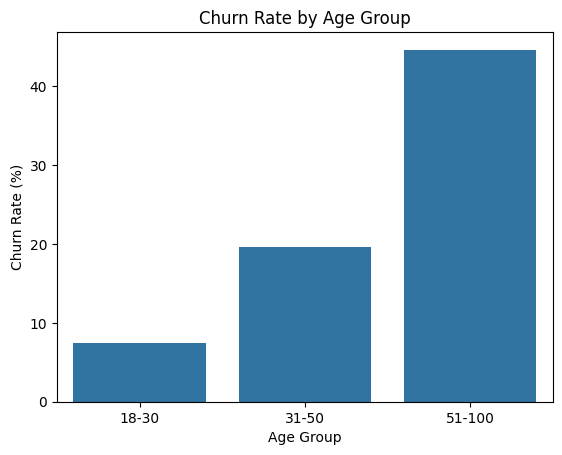

In [ ]:
age_bins = [18, 30, 50, 100]  # Define the age boundaries
age_labels = ['18-30', '31-50', '51-100'] # Define labels for the bins
age_churn = cc_data.groupby(pd.cut(cc_data["Age"], bins=age_bins, labels=age_labels), observed=False)["Churn"].mean()*100
sns.barplot(x=age_churn.index, y=age_churn)
plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()     # PERCENTAGE RATE AT WHICH CUSTOMERS OF DIFFERENT AGE GROUPS CHURN

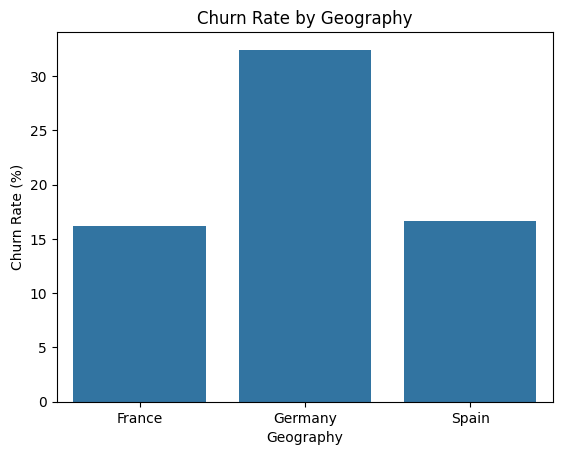

In [ ]:
geo_churn = cc_data.groupby("Geography")["Churn"].mean()*100
sns.barplot(x=geo_churn.index, y=geo_churn)
plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.show()   # THE PERCENTAGE RATE AT WHICH CUSTOMERS OF DIFFERENT GEOGRAPHICAL LOCATIONS CHURN

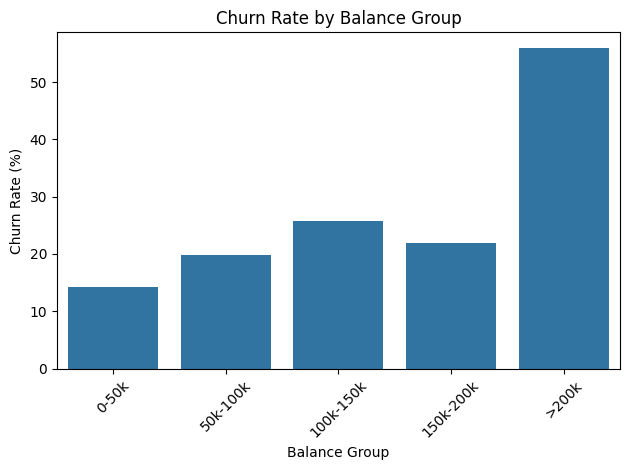

In [ ]:
balance_bins = [0, 50000, 100000, 150000, 200000, cc_data['Balance'].max()] # Define balance boundaries
balance_labels = ['0-50k', '50k-100k', '100k-150k', '150k-200k', '>200k'] # Define labels

# Group by binned Balance and calculate churn rate
bal_churn = cc_data.groupby(pd.cut(cc_data['Balance'], bins=balance_bins, labels=balance_labels, include_lowest=True), observed=False)['Churn'].mean() * 100

# Create the bar plot
sns.barplot(x=bal_churn.index, y=bal_churn)
plt.title('Churn Rate by Balance Group')
plt.xlabel('Balance Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # PERCENTAGE RATE AT WHICH CUSTOMERS CHURN IN RELATION TO THEIR ACCOUNT BALANCE

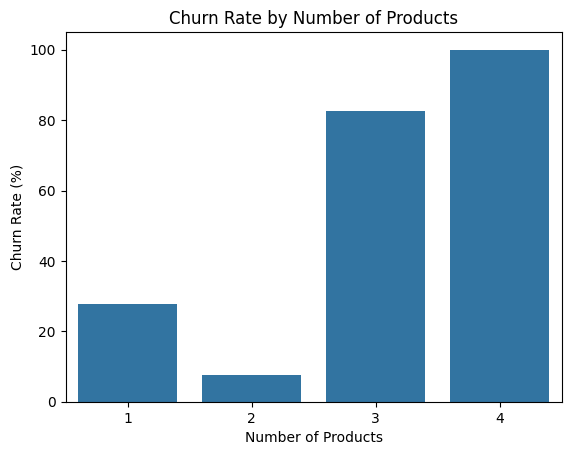

In [ ]:
prod_churn = cc_data.groupby("NumOfProducts")["Churn"].mean()*100
sns.barplot(x=prod_churn.index, y=prod_churn)
plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.show() #PERCENTAGE RATE CUSTOMERS CHURN BY THE NUMBER OF PRODUCTS THEY BUY FROM THE BANK

In [ ]:
# PHASE 3
# ADDING NEW FEATURES FOR LOGISTIC REGRESSION

In [ ]:
cc_data["Estimated_Revenue"] = (cc_data["Balance"] * 0.03).round(2)       # Assuming an Annual net interest margin of 3%
                                                                          # THE OVERALL AMOUNT THE BANK EARNS FROM EACH CUSTOMER

In [ ]:
cc_data["Monthly_Revenue"] = (cc_data["Estimated_Revenue"] / 12).round(2)  # AMOUNT THE BANK EARNS MONTHLY

In [ ]:
cc_data["clv"] = cc_data["Monthly_Revenue"] * cc_data["Tenure"]             # CUSTOMER'S OVERALL LIFETIME VALUE

In [ ]:
cc_data["Engagement_Score"] = cc_data["NumOfProducts"] + cc_data["IsActiveMember"]

In [ ]:
cc_data["Bal_Sal_Ratio"] = cc_data["Balance"] / cc_data["Estimated_Revenue"]
cc_data["Bal_Sal_Ratio"] = cc_data["Bal_Sal_Ratio"].fillna(0)

In [ ]:
cc_data["Gender"] = cc_data["Gender"].map({'Male' : 1, 'Female' : 0})   # CONVERTING THE GENDER COLUMN TO NUMERIC FOR REGRESSION

In [ ]:
cc_data = pd.get_dummies(cc_data, columns=["Geography"], drop_first=True)  # Using France as the baseline

In [ ]:
cc_data.head()

In [ ]:
# PHASE 4
# LET'S RUN OUR MODELS

In [ ]:
X = cc_data.drop(columns=["Churn"], axis=1)
y = cc_data["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8115
[[1544   63]
 [ 314   79]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.56      0.20      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC AUC: 0.7785436172217287


In [ ]:
# Using Random forest model

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.868
ROC AUC: 0.8612938622534048


In [ ]:
# Identify Important churn drivers

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)  # AGE IS THE HIGHEST DRIVER OF CHURN

,0
Age,0.204542
EstimatedSalary,0.102062
CreditScore,0.098714
NumOfProducts,0.093418
Engagement_Score,0.069121
Estimated_Revenue,0.060231
Balance,0.059000
clv,0.058995
Monthly_Revenue,0.058696
Bal_Sal_Ratio,0.053024


Text(0.5, 1.0, 'Feature Importance')

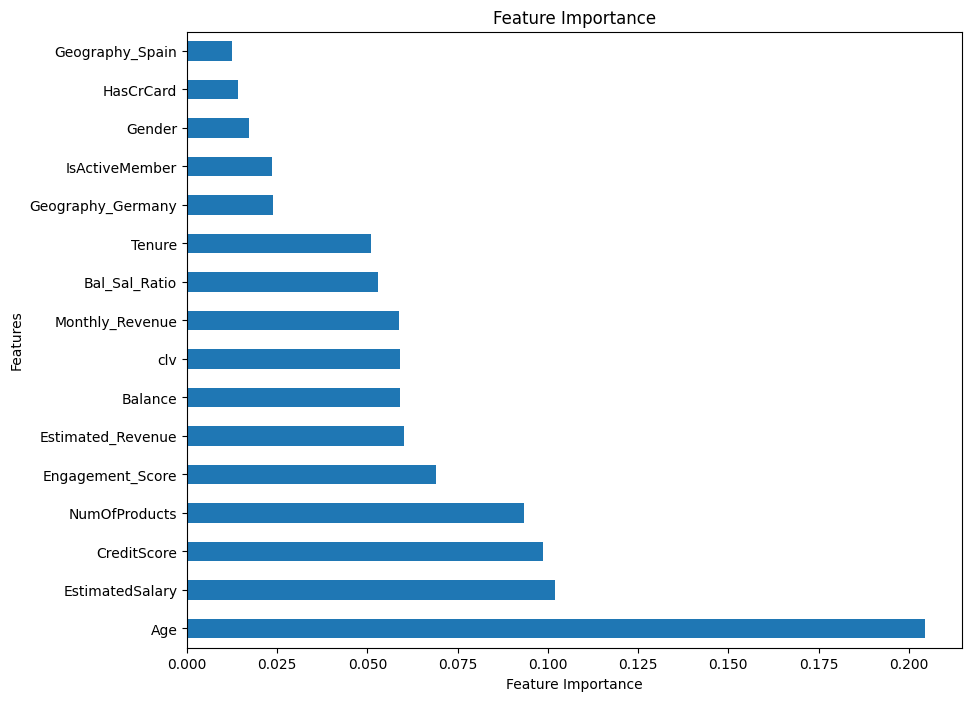

In [ ]:
feature_importance.plot(kind='barh', figsize=(10, 8))
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance')

In [ ]:
# PHASE 5
# Revenue at risk

In [ ]:
cc_data_test = X_test.copy()

cc_data_test["Churn_Probability"] = rf_prob
cc_data_test["Balance"] = cc_data.loc[X_test.index, "Balance"]
cc_data_test["Tenure"] = cc_data.loc[X_test.index, "Tenure"]

In [ ]:
cc_data_test["Revenue_at_risk"] = cc_data_test["Churn_Probability"] * cc_data_test["Monthly_Revenue"]
total_risk = cc_data_test["Revenue_at_risk"].sum()
total_risk                                            # THE COMPANY STANDS TO LOSE $97,029 IF PROPER RETENTION STRATEGIES ARE NOT PUT IN PLACE

np.float64(97029.4936)

In [ ]:
top_risk_cus = cc_data_test.sort_values(by="Revenue_at_risk", ascending=False).head()
top_risk_cus       # THESE ARE THE TOP 5 CUSTOMERS THE COMAPNY NEEDS TO FOCUS IT'S RETENTION STRATEGIES ON

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Estimated_Revenue,Monthly_Revenue,clv,Engagement_Score,Bal_Sal_Ratio,Geography_Germany,Geography_Spain,Churn_Probability,Revenue_at_risk
8683,697,0,49,7,195238.29,4,0,1,131083.56,5857.15,488.10,3416.70,5,33.333326,False,False,0.95,463.6950
6221,513,0,45,0,164649.52,3,1,0,49915.52,4939.49,411.62,0.00,3,33.333304,False,False,0.94,386.9228
8897,603,1,51,8,186825.57,1,1,0,93739.71,5604.77,467.06,3736.48,1,33.333316,False,False,0.80,373.6480
7632,736,1,43,4,202443.47,1,1,0,72375.03,6073.30,506.11,2024.44,1,33.333356,False,False,0.73,369.4603
5137,698,0,51,6,144237.91,4,1,0,157143.61,4327.14,360.60,2163.60,4,33.333313,False,False,0.99,356.9940


In [ ]:
cc_data_test["clv"] = cc_data_test["Monthly_Revenue"] * cc_data_test["Tenure"]
cc_data_test["Value_Segment"] = pd.qcut(
    cc_data_test["clv"],
    q=3,
    labels=["Low Value", "High Value"], # Adjusted labels to match likely 2 bins
    duplicates='drop')       # CLASSIFIED THE VALUE OF EACH CUSTOMER IN LOW AND HIGH VALUE CUSTOMERS TO INDICATE WHICH TO DIRECT RETENTION STRATEGIES TO

In [ ]:
pri_cus = cc_data_test[(cc_data_test["Value_Segment"] == "High Value") & (cc_data_test["Churn_Probability"] >= 0.6)]
pri_cus.sort_values(by="Revenue_at_risk", ascending=False).head()   # ALSO INDICATED THE RATE OF CHURN FOR EACH OF THEM

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Estimated_Revenue,Monthly_Revenue,clv,Engagement_Score,Bal_Sal_Ratio,Geography_Germany,Geography_Spain,Churn_Probability,Revenue_at_risk,Value_Segment
8683,697,0,49,7,195238.29,4,0,1,131083.56,5857.15,488.10,3416.70,5,33.333326,False,False,0.95,463.6950,High Value
8897,603,1,51,8,186825.57,1,1,0,93739.71,5604.77,467.06,3736.48,1,33.333316,False,False,0.80,373.6480,High Value
7632,736,1,43,4,202443.47,1,1,0,72375.03,6073.30,506.11,2024.44,1,33.333356,False,False,0.73,369.4603,High Value
5137,698,0,51,6,144237.91,4,1,0,157143.61,4327.14,360.60,2163.60,4,33.333313,False,False,0.99,356.9940,High Value
7216,679,1,41,8,147726.98,3,1,0,172749.40,4431.81,369.32,2954.56,3,33.333329,False,False,0.96,354.5472,High Value


In [ ]:
# PHASE 6
# A QUICK COMPARISON OF THE RANDOM FOREST REGRESSION MODEL AND THE LOGISTIC REGRESSION MODEL

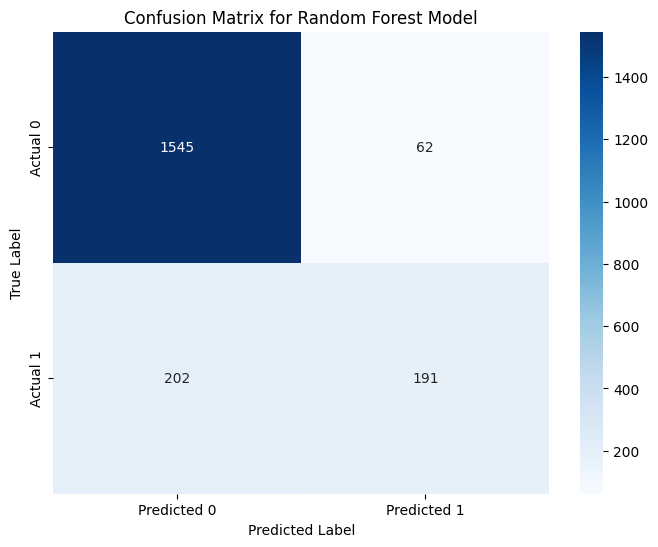

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the Random Forest model
cm_rf = confusion_matrix(y_test, rf_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

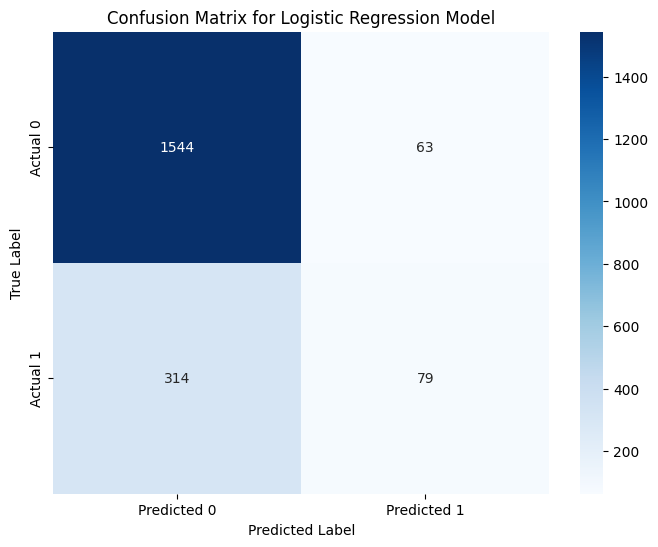

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

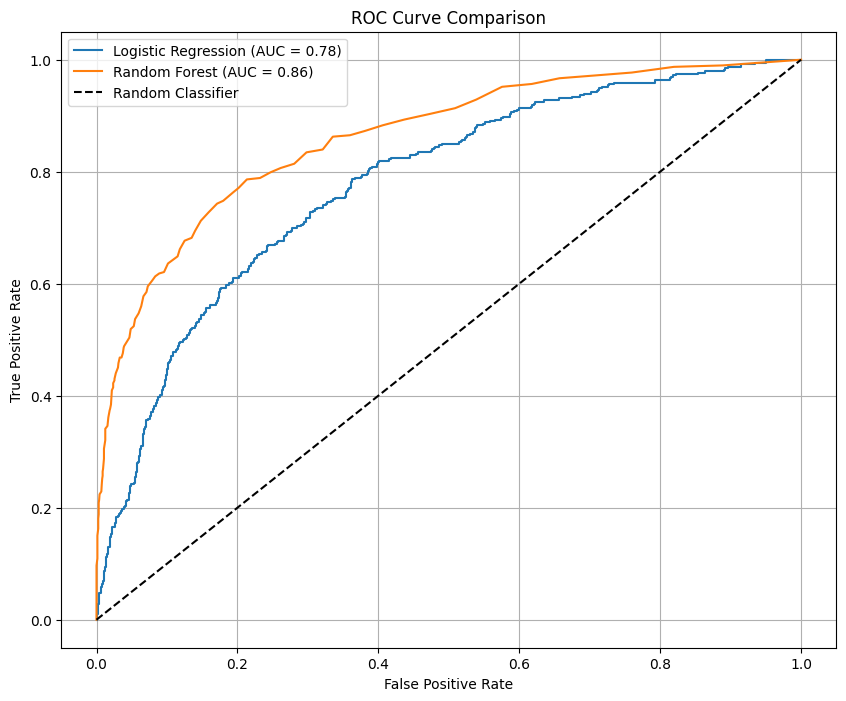

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get ROC curve data for Logistic Regression
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob)

# Get ROC curve data for Random Forest
# Ensure rf_prob is defined (if not already from prior execution)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_prob)

# Plot the ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Dashed diagonal line for a random classifier

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()